In [5]:
!pip install scikit-learn

  Using cached scikit_learn-1.3.2-cp38-cp38-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
Using cached scikit_learn-1.3.2-cp38-cp38-win_amd64.whl (9.3 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)


In [7]:
!pip install catboost

   ---------------------------------------- 0.0/100.3 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.3 MB 8.5 MB/s eta 0:00:12
    --------------------------------------- 1.8/100.3 MB 4.4 MB/s eta 0:00:23
    --------------------------------------- 1.8/100.3 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.1/100.3 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 3.9/100.3 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 4.5/100.3 MB 3.6 MB/s eta 0:00:27
   - -------------------------------------- 5.0/100.3 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 5.5/100.3 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 6.0/100.3 MB 3.1 MB/s eta 0:00:31
   -- ------------------------------------- 6.6/100.3 MB 3.1 MB/s eta 0:00:31
   -- ------------------------------------- 7.1/100.3 MB 3.1 MB/s eta 0:00:30
   --- ------------------------------------ 7.6/100.3 MB 3.0 MB/s eta 0

In [8]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 8.2 MB/s eta 0:00:16
    --------------------------------------- 1.6/124.9 MB 5.2 MB/s eta 0:00:24
    --------------------------------------- 2.4/124.9 MB 4.6 MB/s eta 0:00:27
   - -------------------------------------- 3.1/124.9 MB 4.3 MB/s eta 0:00:29
   - -------------------------------------- 3.9/124.9 MB 4.1 MB/s eta 0:00:30
   - -------------------------------------- 4.7/124.9 MB 4.1 MB/s eta 0:00:30
   - -------------------------------------- 5.5/124.9 MB 4.0 MB/s eta 0:00:30
   -- ------------------------------------- 6.3/124.9 MB 4.0 MB/s eta 0:00:30
   -- ------------------------------------- 7.1/124.9 MB 4.0 MB/s eta 0:00:30
   -- ------------------------------------- 7.6/124.9 MB 4.0 MB/s eta 0:00:30
   -- ------------------------------------- 8.7/124.9 MB 3.9 MB/s eta 0:00:30
   --- ------------------------------------ 9.4/124.9 MB 3.9 MB/s eta 0

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


In [10]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
print("Categories in 'gender' variable:  " ,end="")
print (df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'math score' variable: ", end=" ")
print(df['math score'].unique())

print("Categories in 'reading score' variable:" , end=" ")
print(df['reading score']. unique ())

print("Categories in 'writing score ' variable:" , end=" ")
print(df['writing score']. unique ())


Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'math score' variable:  [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
Categories in 'reading score' variable: [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24

Preparing X and Y variables

In [13]:
X = df.drop(columns=['math score'],axis=1)

In [15]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [17]:
y=df['math score']

In [18]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [19]:
#create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
        
    ]
)

In [20]:
X=preprocessor.fit_transform(X)

In [21]:
X.shape

(1000, 19)

In [25]:
#seperate dataset into train and test 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

Create an Evaluate Function to give all metrics after model Training

In [29]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true, predicted)
    mse=mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2square = r2_score(true, predicted)
    return mae,rmse,r2square

In [33]:
models = {
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()

}

model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)#Train model

    #Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluate Train and Test dataset

    model_train_mae, model_train_rmse,model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    print('Model Perormance for Training set')
    print("RMSE : {:.4F}".format(model_train_rmse))
    print("MAE : {:.4F}".format(model_train_mae))
    print("R2SCORE : {:.4F}".format(model_train_r2))


    print('----------------------------------------------')

    print('Model Performance for Test set')
    print("RMSE : {:.4F}".format(model_test_rmse))
    print("MAE : {:.4F}".format(model_test_mae))
    print("R2SCORE : {:.4F}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print('='*35)
    print('\n')

Linear Regression
Model Perormance for Training set
RMSE : 5.3243
MAE : 4.2671
R2SCORE : 0.8743
----------------------------------------------
Model Performance for Test set
RMSE : 5.3960
MAE : 4.2158
R2SCORE : 0.8803


Lasso
Model Perormance for Training set
RMSE : 6.5938
MAE : 5.2063
R2SCORE : 0.8071
----------------------------------------------
Model Performance for Test set
RMSE : 6.5197
MAE : 5.1579
R2SCORE : 0.8253


Ridge
Model Perormance for Training set
RMSE : 5.3233
MAE : 4.2650
R2SCORE : 0.8743
----------------------------------------------
Model Performance for Test set
RMSE : 5.3904
MAE : 4.2111
R2SCORE : 0.8806


K-Neighbors Regressor
Model Perormance for Training set
RMSE : 5.7077
MAE : 4.5167
R2SCORE : 0.8555
----------------------------------------------
Model Performance for Test set
RMSE : 7.2530
MAE : 5.6210
R2SCORE : 0.7838


Decision Tree
Model Perormance for Training set
RMSE : 0.2795
MAE : 0.0187
R2SCORE : 0.9997
----------------------------------------------
M

Results

In [35]:
import pandas as pd

In [37]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model name','R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880345
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.849591
8,AdaBoost Regressor,0.847297
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.717595


Linear Regrssion

In [39]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("Accuaracy of the model id %.2f" %score)

Accuaracy of the model id 88.03


Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

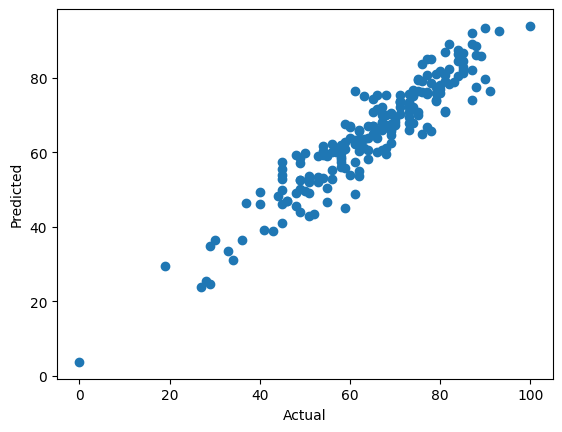

In [41]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

Difference between Actual and Predicted Values

In [42]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted value,Difference
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
